In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib
import yfinance as yf

# 행(row) 다 보기
pd.set_option('display.max_rows', None)

# 열(column) 다 보기
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', None)
from PublicDataReader import Ecos

service_key = "2G5XUDEN750MGRZM37GF"
api = Ecos(service_key)
df = api.get_statistic_table_list()
df.head()

,상위통계표코드,통계표코드,통계명,시점,검색가능여부,출처
0,*,0000000001,1. 통화/금융,None,N,None
1,0000000001,0000000620,1.1. 통화/유동성(신지표),None,N,None
2,0000000620,0000000621,1.1.1. 본원통화,None,N,None
3,0000000621,0000000622,1.1.1.1. 본원통화 구성내역,None,N,None
4,0000000622,102Y004,"1.1.1.1.1. 본원통화 구성내역(평잔, 계절조정계열)",M,Y,None


### M2(광의통화)

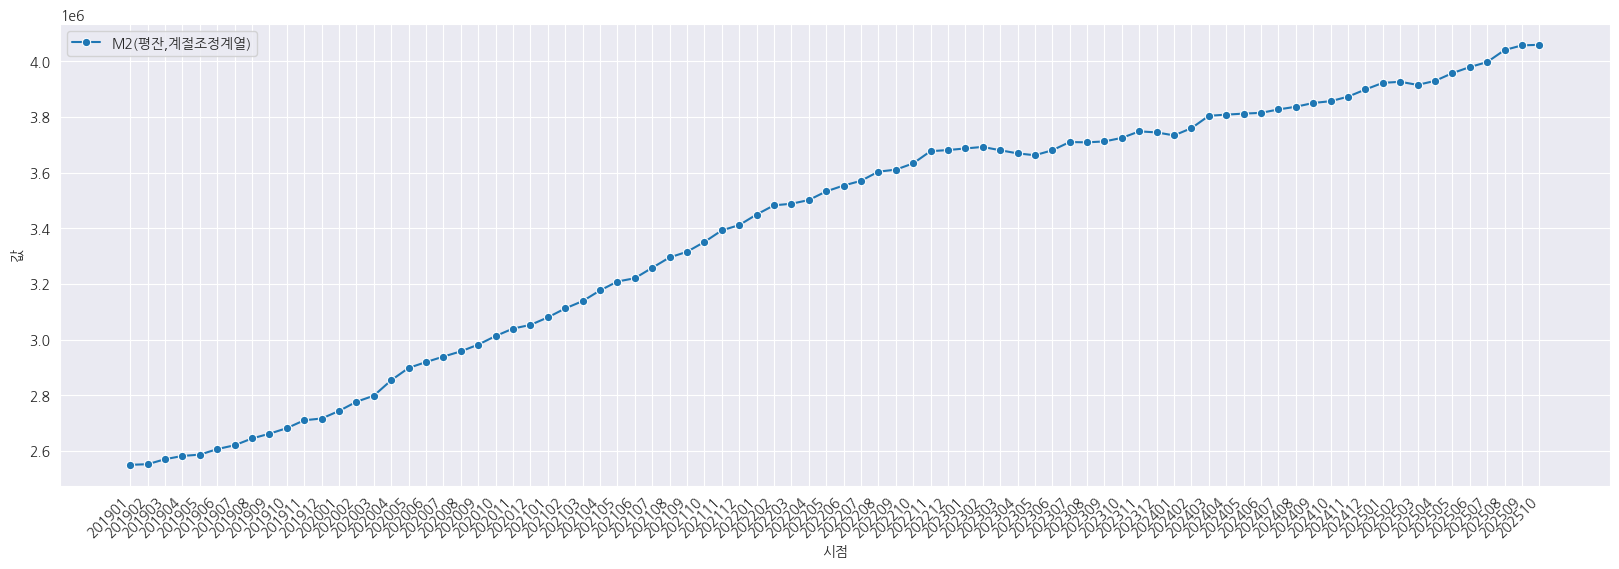

In [3]:
df_m2 = api.get_statistic_search(통계표코드="161Y005", 주기="M", 검색시작일자="201901", 검색종료일자="202612")
df_m2['값'] = df_m2['값'].astype(float)

plt.figure(figsize=(20,6))  # 그림 넓게
sns.lineplot(x="시점", y="값", data=df_m2[df_m2['통계항목명1'] == 'M2(평잔,계절조정계열)'], hue='통계항목명1', marker='o')

# x축 레이블 회전
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

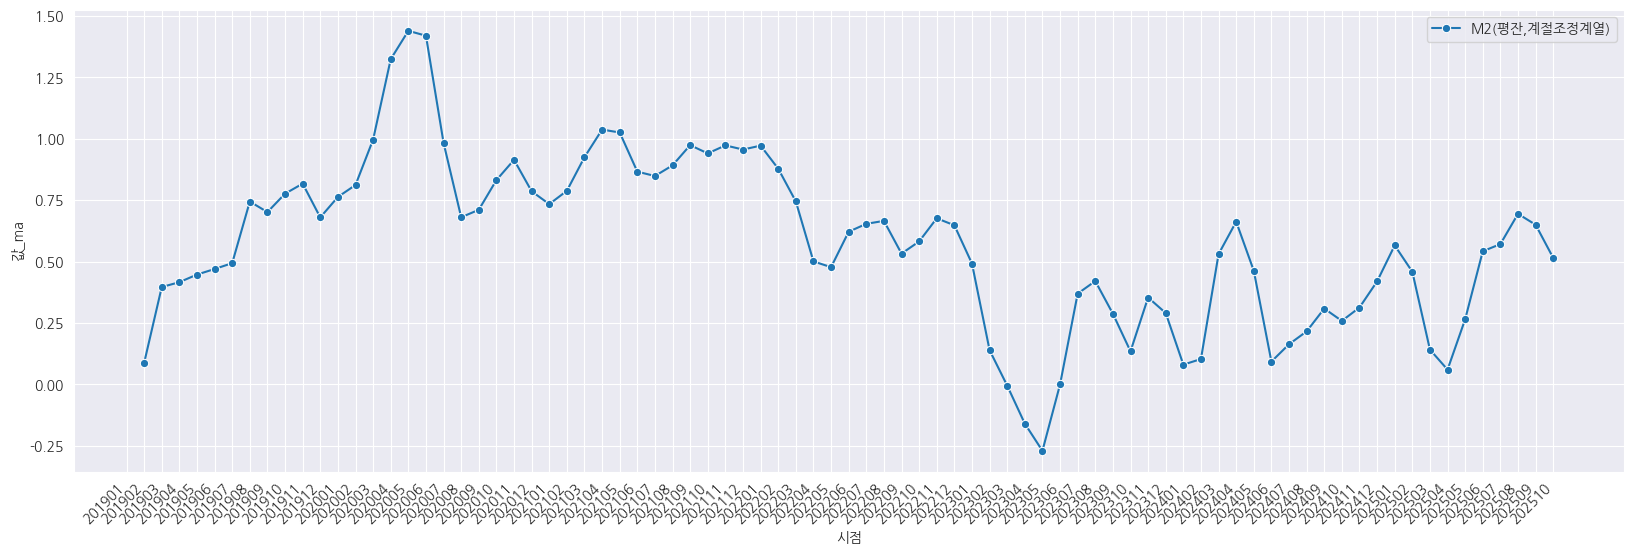

In [4]:
df_tmp = df_m2[df_m2['통계항목명1'] == 'M2(평잔,계절조정계열)'].copy()
df_tmp['값_prev'] = df_tmp['값'].shift(1)
df_tmp['값_ratio'] = ((df_tmp['값'] / df_tmp['값_prev']) - 1) * 100
df_tmp['값_ma'] = df_tmp['값_ratio'].rolling(window=3, min_periods=1).mean()

plt.figure(figsize=(20,6))  # 그림 넓게
sns.lineplot(x="시점", y="값_ma", data=df_tmp, hue='통계항목명1', marker='o')

# x축 레이블 회전
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

In [5]:
df_m2_tot = df_m2[df_m2['통계항목명1'] == 'M2(평잔,계절조정계열)'][['시점','값']].rename(columns={'값':'tot'}).copy()
df_m2_else = df_m2[df_m2['통계항목명1'] != 'M2(평잔,계절조정계열)'].copy()

df_m2_comp = df_m2_else.merge(df_m2_tot, on='시점')
df_m2_comp['ratio'] = np.round((df_m2_comp['값'] / df_m2_comp['tot']), 2) * 100
df_m2_comp.head()

,통계표코드,통계명,통계항목코드1,통계항목명1,통계항목코드2,통계항목명2,통계항목코드3,통계항목명3,통계항목코드4,통계항목명4,단위,WGT,시점,값,tot,ratio
0,161Y005,"1.1.3.1.1. M2 상품별 구성내역(평잔, 계절조정계열)",BBHS01,현금통화,None,None,None,None,None,None,십억원,None,201901,103481.4,2550186.4,4.0
1,161Y005,"1.1.3.1.1. M2 상품별 구성내역(평잔, 계절조정계열)",BBHS02,요구불예금,None,None,None,None,None,None,십억원,None,201901,232453.4,2550186.4,9.0
2,161Y005,"1.1.3.1.1. M2 상품별 구성내역(평잔, 계절조정계열)",BBHS03,수시입출식저축성예금,None,None,None,None,None,None,십억원,None,201901,515350.1,2550186.4,20.0
3,161Y005,"1.1.3.1.1. M2 상품별 구성내역(평잔, 계절조정계열)",BBHS04,MMF 지분,None,None,None,None,None,None,십억원,None,201901,87130.6,2550186.4,3.0
4,161Y005,"1.1.3.1.1. M2 상품별 구성내역(평잔, 계절조정계열)",BBHS05,만기2년미만정기예적금,None,None,None,None,None,None,십억원,None,201901,1107508.8,2550186.4,43.0


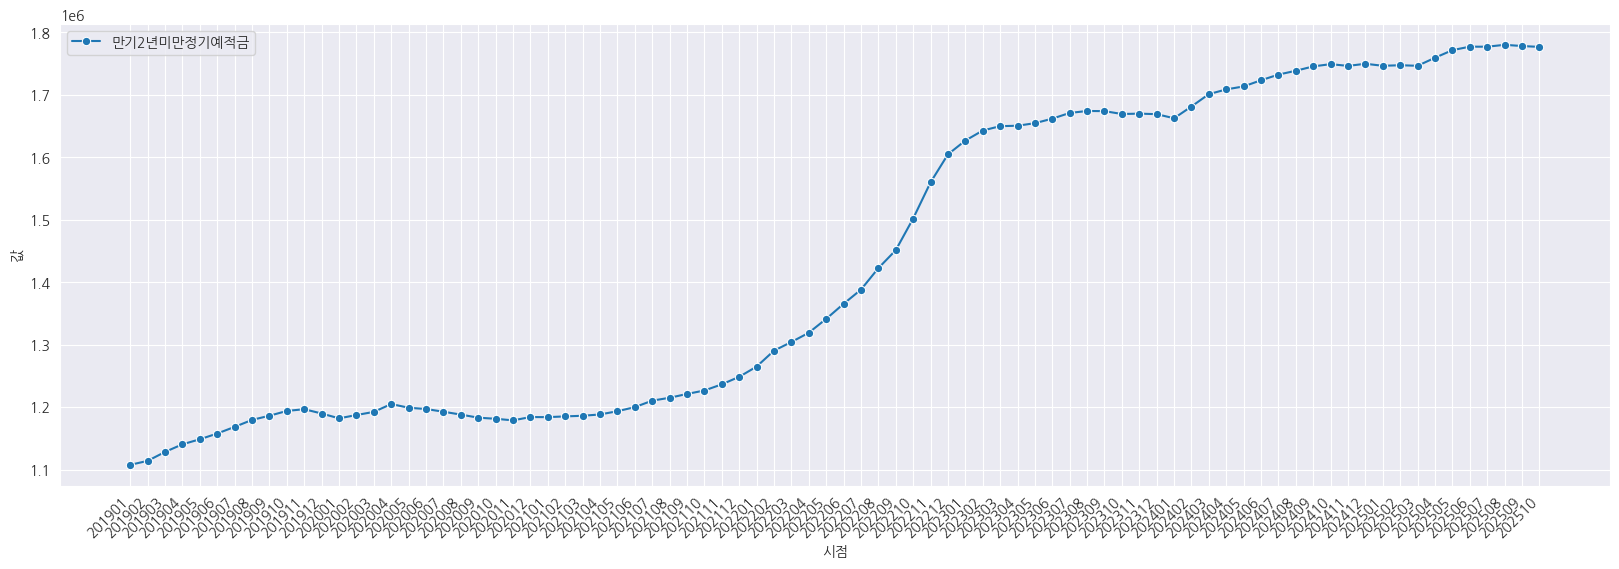

In [6]:
plt.figure(figsize=(20,6))  # 그림 넓게
sns.lineplot(x="시점", y="값",
             data=df_m2_comp[df_m2_comp['통계항목명1'].isin([ '만기2년미만정기예적금'])],
             hue='통계항목명1', marker='o')

# x축 레이블 회전
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

### 유입자금 방향

In [7]:
df_flow = api.get_statistic_search(통계표코드="161Y015", 주기="M", 검색시작일자="201901", 검색종료일자="202612")
df_flow['값'] = df_flow['값'].astype(float)

In [22]:
list_input_var = [ "요구불예금", "수시입출식저축성예금", "CMA", "MMF 지분", "환매조건부채권매도"]
list_output_var = ['예수금 (M2 제외)', '채무증권(M2 제외)', '자본계정']

df_flow_input = (
    pd.pivot(data=df_flow[df_flow['통계항목명1'].isin(list_input_var)], index='시점', columns='통계항목명1', values='값').fillna(0).reset_index()
)

df_flow_output = (
    pd.pivot(data=df_flow[df_flow['통계항목명1'].isin(list_output_var)], index='시점', columns='통계항목명1', values='값').fillna(0).reset_index()
)

df_flow_merged = df_flow_input.merge(df_flow_output, on ='시점')
df_flow_merged['시점'] = pd.to_datetime(df_flow_merged['시점'], format='%Y%m')

In [23]:
df_flow_merged.tail()

통계항목명1,시점,CMA,MMF 지분,수시입출식저축성예금,요구불예금,환매조건부채권매도,예수금 (M2 제외),자본계정,채무증권(M2 제외)
77,2025-06-01,85303.3,153047.0,732923.2,394565.2,7567.7,339397.5,415125.5,130700.9
78,2025-07-01,86503.9,172677.4,717006.2,386964.9,9679.5,346758.2,419798.5,134995.1
79,2025-08-01,87799.5,173163.5,724602.7,398942.0,11565.8,347662.7,421352.7,134526.3
80,2025-09-01,90457.9,154587.4,754230.5,404932.9,7794.2,354033.9,424953.3,128776.2
81,2025-10-01,91936.6,167013.2,736837.1,391973.3,7960.4,358345.0,426593.4,129423.6


#### 주식시장으로 돈이 몰리나?
- 요구불예금 : 언제든지 요구하면 바로 인출 가능한 예금 (보통예금, 당좌예금, 기업결제용 계좌, 체크카드 연결 계좌, 급여통장)
- CMA : 증권사가 운영하는 이자 붙는 현금 계좌
- MMF : 초단기 금융상품에 투자하는 현금 대용 펀드 (요구불예금 - CMA - 주식/채권), 보통 국공채 단기물이나 RP, 통안채에 투자해

- **요구불예금가 줄어들면서 CMA나 MMF로 증가하는 것으로 보아 주식시장으로 갈 준비를 하고 있음**

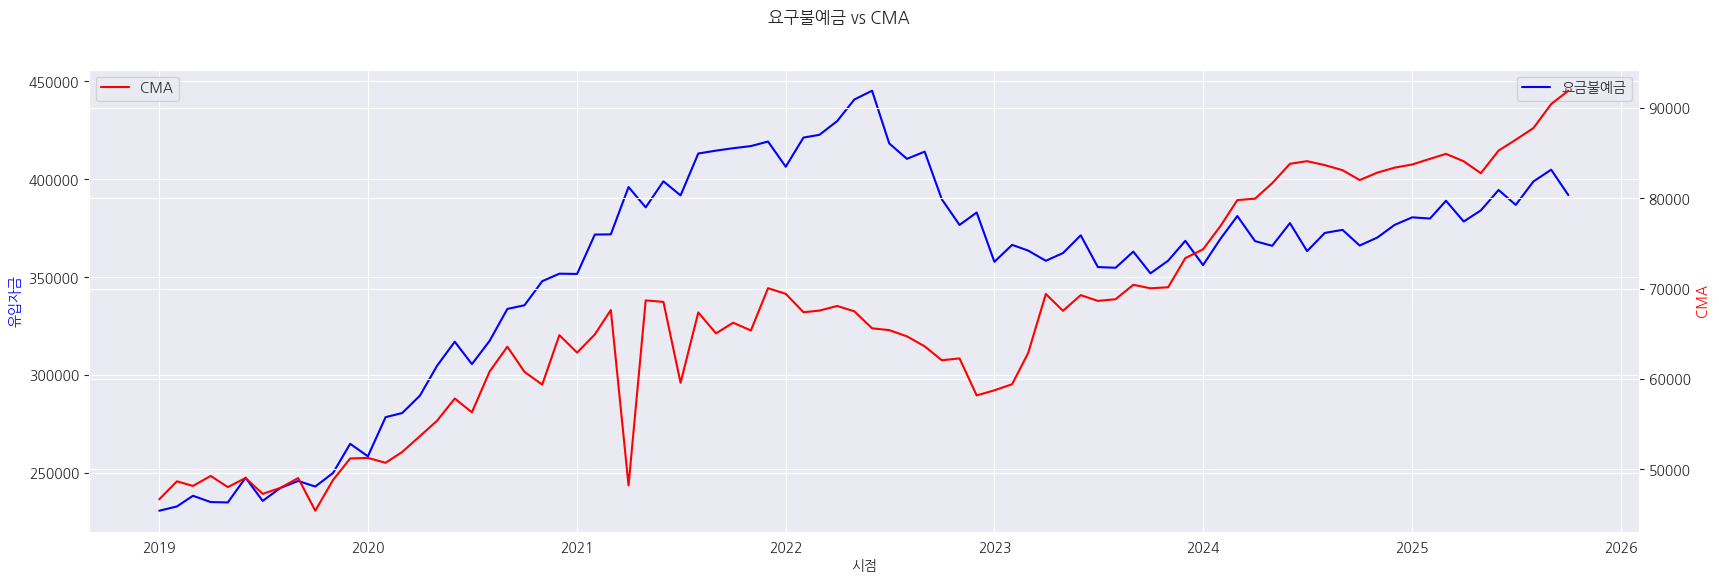

In [32]:
fig, ax1 = plt.subplots(figsize=(20,6))
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["요구불예금"], ax=ax1, label="요금불예금", color='blue')
ax1.set_ylabel('유입자금', color='blue')

ax2 = ax1.twinx()
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["CMA"], ax=ax2, label="CMA", color='red')
ax2.set_ylabel('CMA', color='red')

fig.suptitle('요구불예금 vs CMA')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

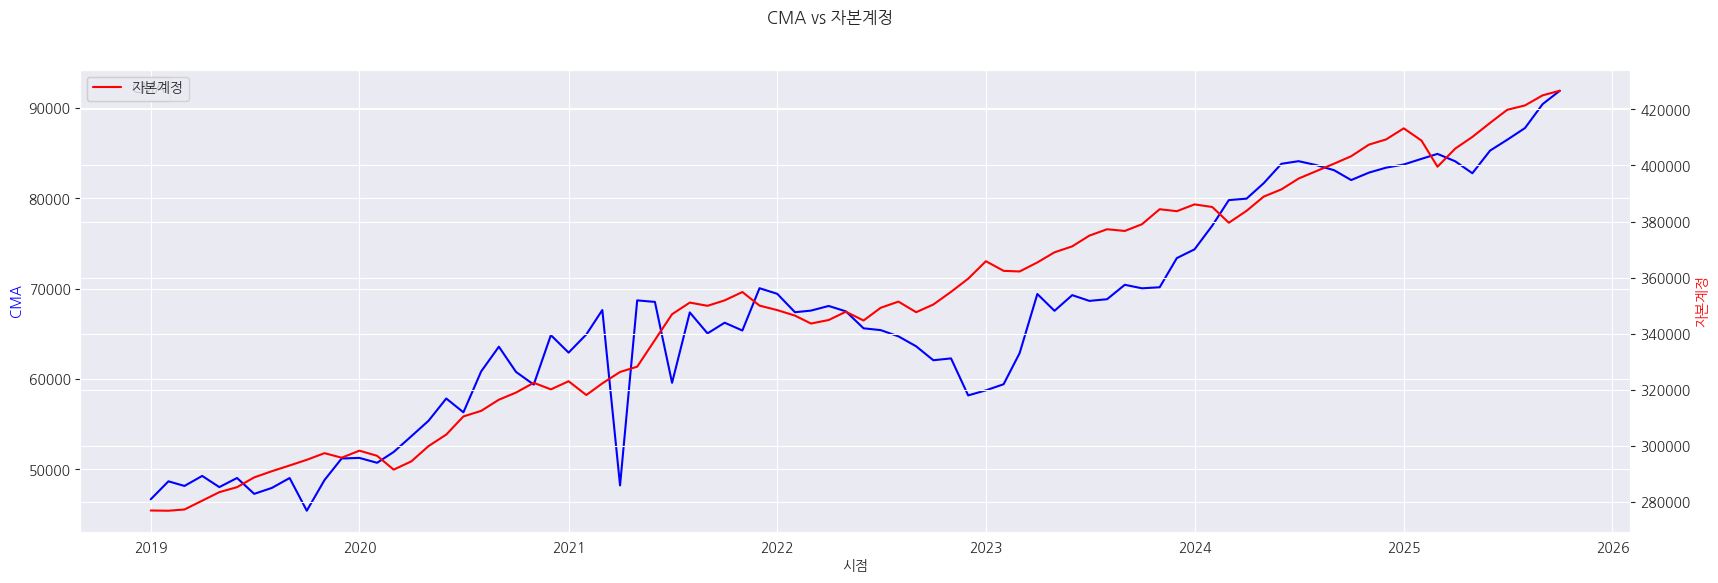

In [33]:
fig, ax1 = plt.subplots(figsize=(20,6))
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["CMA"], ax=ax1, label="CMA", color='blue')
ax1.set_ylabel('CMA', color='blue')

ax2 = ax1.twinx()
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["자본계정"], ax=ax2, label="자본계정", color='red')
ax2.set_ylabel('자본계정', color='red')

fig.suptitle('CMA vs 자본계정')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

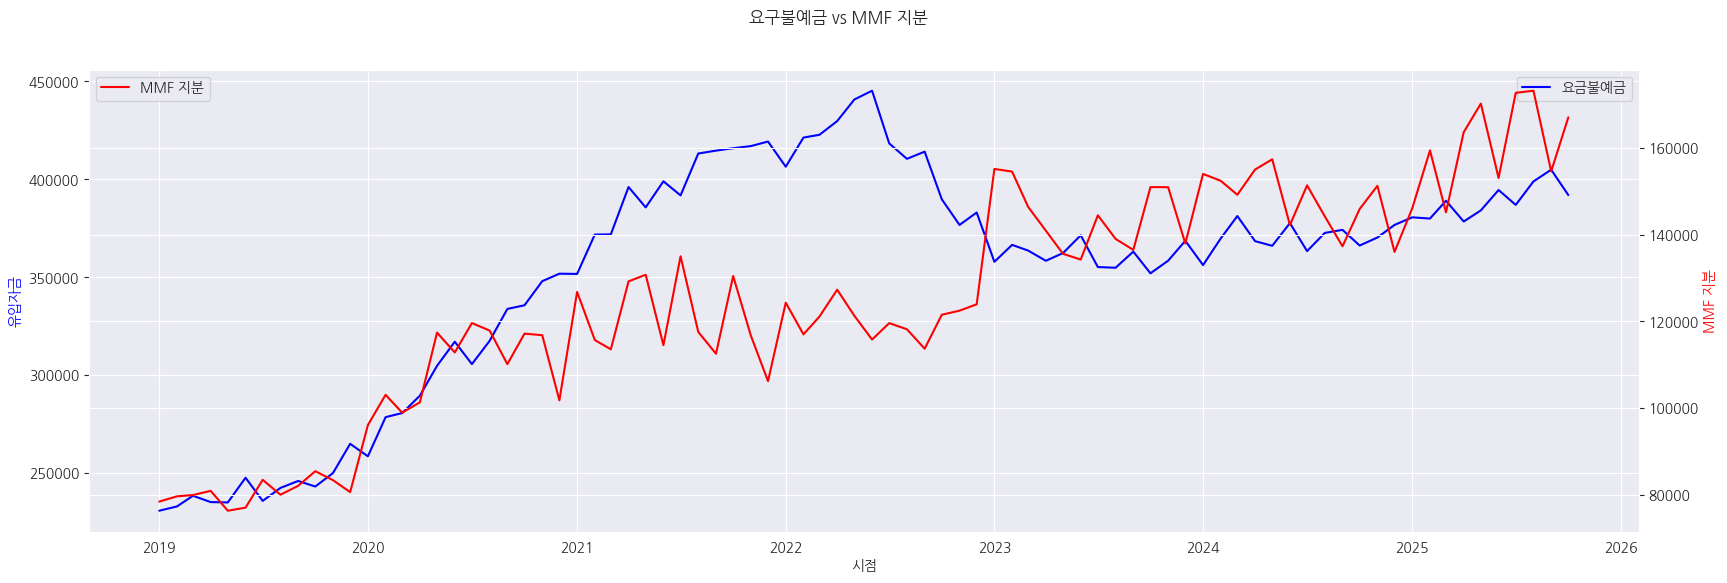

In [35]:
fig, ax1 = plt.subplots(figsize=(20,6))
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["요구불예금"], ax=ax1, label="요금불예금", color='blue')
ax1.set_ylabel('유입자금', color='blue')

ax2 = ax1.twinx()
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["MMF 지분"], ax=ax2, label="MMF 지분", color='red')
ax2.set_ylabel('MMF 지분', color='red')

fig.suptitle('요구불예금 vs MMF 지분')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

#### 예수금
- 주식시장과 반대로 가는 성격
- 은행 안에서 묶인 돈
- 장기,조건부,유동성 낮금은 예금


#### 채무증권
- 채권시장
- 금융채, 회사채, 장기채

#### 자본계정
- 주식
- 펀드
- 기업자충본 확충

- 자본계정과 예수금이 같이 움직인다는 것은 총 유동성 확장 국면 즉, 돈 자체가 늘어난다는 의미
    + 임금, 이자, 배당 증가
    + 정부 지출
    + 기업 이익 확대


- 자본계정과 채무증권이 음의 관계인 이유
    + 채무증권은 확정수익이자 금리 방향 베팅, 위험 해피 성향이라면 자본계정은 변동 수익, 성장 기대, 위험 감수
    + 그래서 대체 관계가 됨

- 금리 고점 인식이 높으면, 채권 선호가 높고 자본계정은 떨어짐
- 성장 기대되면 자본계정이 높고 채무증권이 낮음

- 국면별
    + **예수금 높고, 자본계정 높으면 초기 확장**
    + **예수금 낮고, 자본계정 높으면 사람들이 손해 날 가능성을 감수하고 더 높은 수익을 기대하는 자산을 선택하는 국면**
    + **예수금 높고, 자본계정 낮으면 위험 회피**

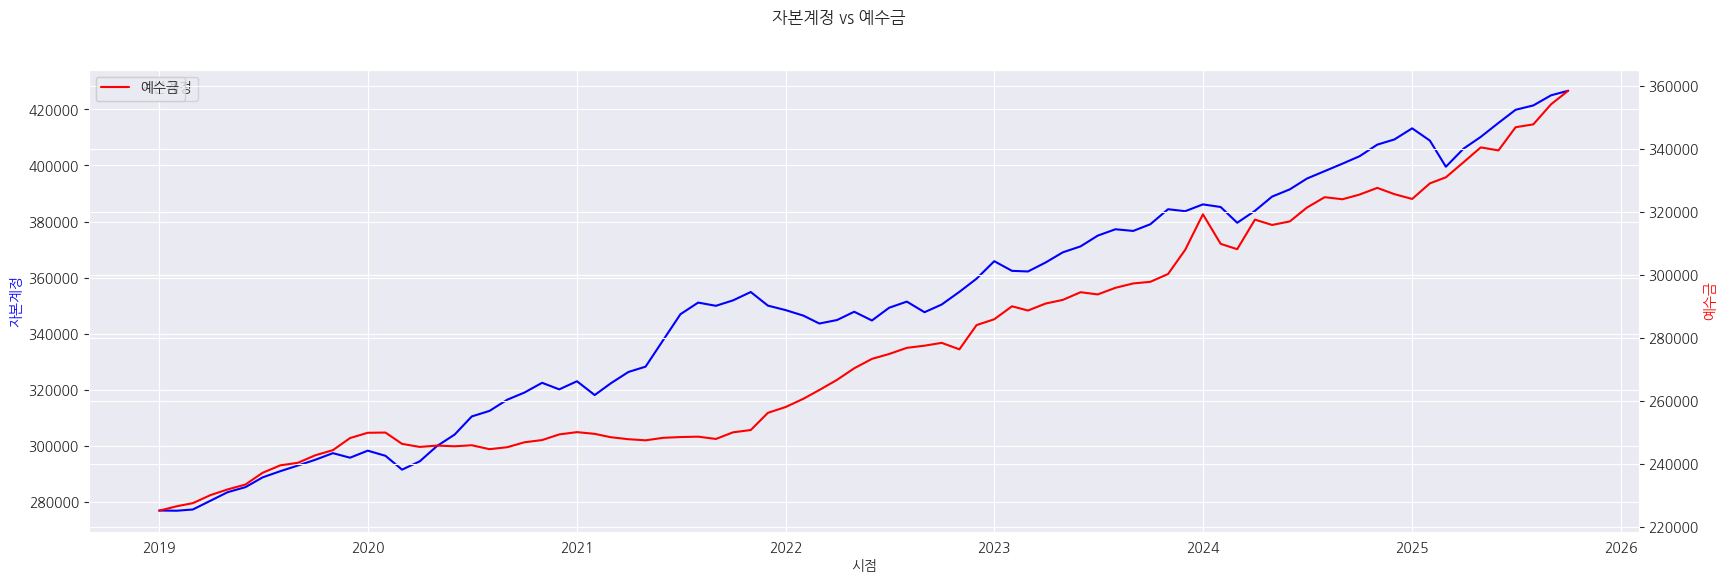

In [37]:
fig, ax1 = plt.subplots(figsize=(20,6))
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["자본계정"], ax=ax1, label="자본계정", color='blue')
ax1.set_ylabel('자본계정', color='blue')

ax2 = ax1.twinx()
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["예수금 (M2 제외)"], ax=ax2, label="예수금", color='red')
ax2.set_ylabel('예수금', color='red')

fig.suptitle('자본계정 vs 예수금')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

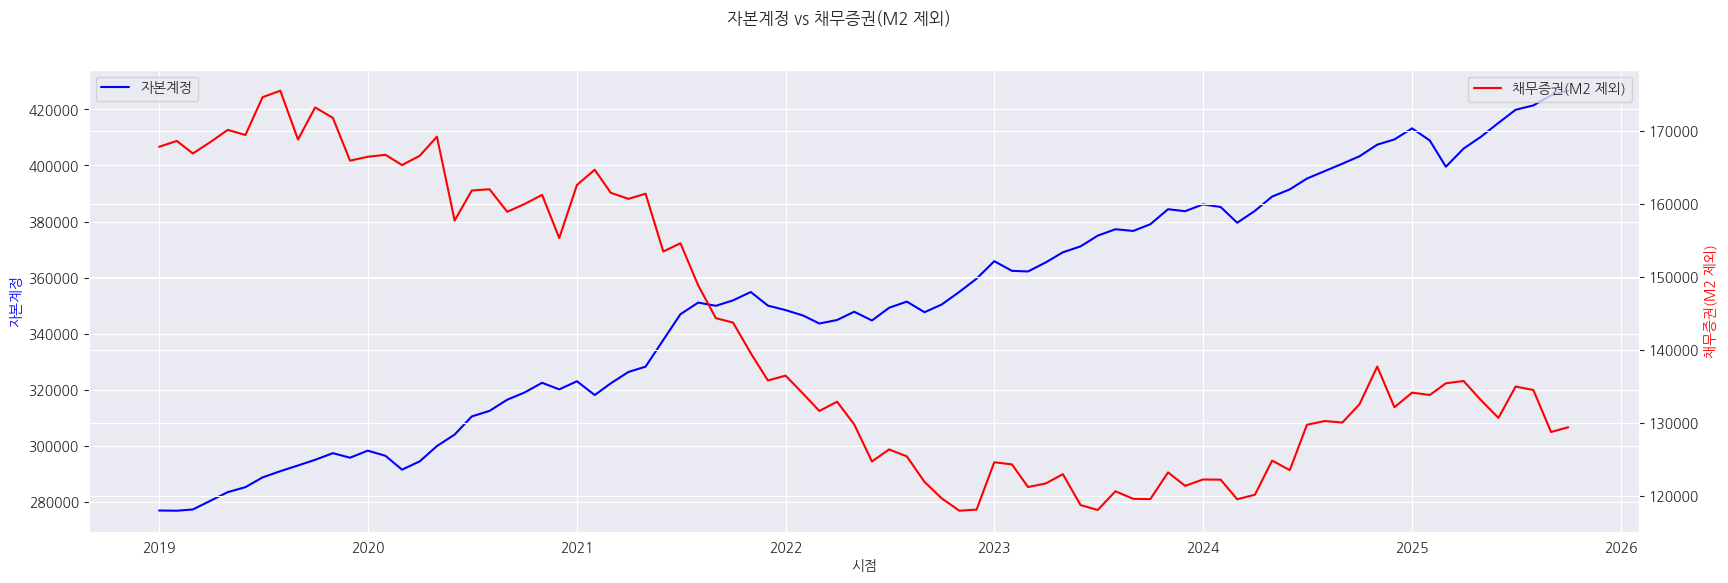

In [38]:
fig, ax1 = plt.subplots(figsize=(20,6))
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["자본계정"], ax=ax1, label="자본계정", color='blue')
ax1.set_ylabel('자본계정', color='blue')

ax2 = ax1.twinx()
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["채무증권(M2 제외)"], ax=ax2, label="채무증권(M2 제외)", color='red')
ax2.set_ylabel('채무증권(M2 제외)', color='red')

fig.suptitle('자본계정 vs 채무증권(M2 제외)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

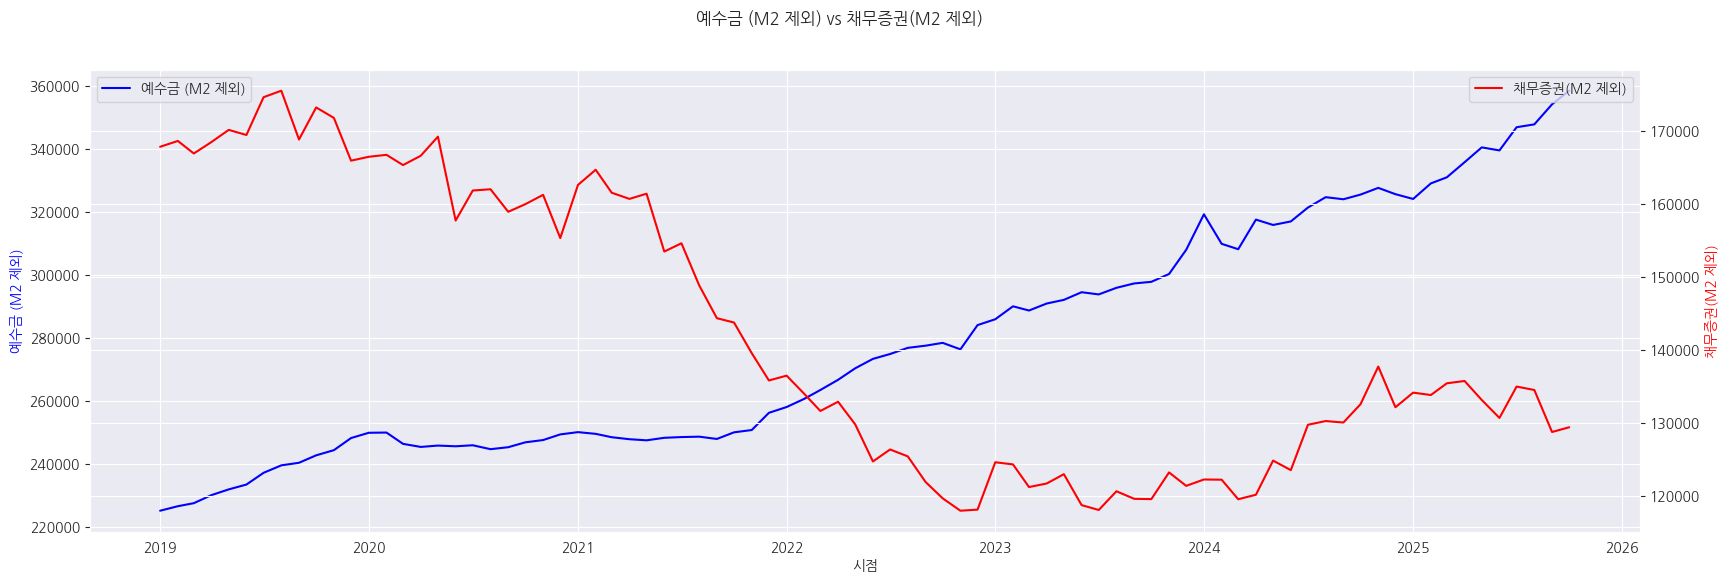

In [39]:
fig, ax1 = plt.subplots(figsize=(20,6))
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["예수금 (M2 제외)"], ax=ax1, label="예수금 (M2 제외)", color='blue')
ax1.set_ylabel('예수금 (M2 제외)', color='blue')

ax2 = ax1.twinx()
sns.lineplot(x=df_flow_merged["시점"], y=df_flow_merged["채무증권(M2 제외)"], ax=ax2, label="채무증권(M2 제외)", color='red')
ax2.set_ylabel('채무증권(M2 제외)', color='red')

fig.suptitle('예수금 (M2 제외) vs 채무증권(M2 제외)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

#### 주식 시장에서 나와야 하는 국면(시장 과열 탐지)
- CMA 거의 비어 있음
- MMF 급감
- 빚(신용) 급증
- 채권 수감요 급감

- 신용융자 잔고(주식을 사기 위해 증권사에서 빌린 돈)
- https://freesis.kofia.or.kr/
- 901Y014 코드 시가총액